# Heart Disease Prediction Using Decision Trees

This notebook builds and compares multiple Decision Tree classifiers using a consistent workflow:

1. Build the model
2. Evaluate train and test performance
3. Visualize the Decision Tree
4. Analyze feature importance

In [ ]:
# Importing the required libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline

In [ ]:
# Reading the csv file and putting it into 'df' object.
df = pd.read_csv('heart_v2.csv')

In [ ]:
df.columns

Index(['age', 'sex', 'BP', 'cholestrol', 'heart disease'], dtype='str')

In [ ]:
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [ ]:
# Putting feature variable to X
X = df.drop('heart disease',axis=1)

# Putting response variable to y
y = df['heart disease']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
X_train.shape, X_test.shape

((189, 4), (81, 4))

# Helper Functions

The following functions are reused throughout the notebook to keep the code clean and avoid repetition.


In [ ]:
from io import StringIO
from IPython.display import Image, display
import pydotplus
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def get_dt_graph(dt_classifier, feature_names, class_names=None):
    """Create a graph object for a trained Decision Tree."""

    if class_names is None:
        class_names = [str(cls) for cls in dt_classifier.classes_]

    dot_data = StringIO()

    export_graphviz(
        dt_classifier,
        out_file=dot_data,
        filled=True,
        rounded=True,
        special_characters=True,
        feature_names=feature_names,
        class_names=class_names
    )

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return graph


def visualize_tree(dt_classifier, feature_names, class_names=None):
    """Display a trained Decision Tree."""

    graph = get_dt_graph(
        dt_classifier,
        feature_names=feature_names,
        class_names=class_names
    )

    display(Image(graph.create_png()))


def evaluate_model(model, X_train, y_train, X_test, y_test):
    """Evaluate a model on both training and testing data."""

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("TRAINING PERFORMANCE")
    print("-" * 50)
    print("Accuracy:", np.round(accuracy_score(y_train, y_train_pred),2))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_train, y_train_pred))

    print("\n" + "=" * 50)

    print("TESTING PERFORMANCE")
    print("-" * 50)
    print("Accuracy:", np.round(accuracy_score(y_test, y_test_pred),2))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))


def show_feature_importance(model, feature_names):
    """Display and visualize Decision Tree feature importance."""

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    display(importance_df)

    plt.figure(figsize=(8, 5))
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.title("Feature Importance")
    plt.gca().invert_yaxis()
    plt.show()

    return importance_df

In [ ]:
help(plt.barh)

Help on function barh in module matplotlib.pyplot:

barh(y: 'float | ArrayLike', width: 'float | ArrayLike', height: 'float | ArrayLike' = 0.8, left: 'float | ArrayLike | None' = None, *, align: "Literal['center', 'edge']" = 'center', data: 'DataParamType' = None, **kwargs) -> 'BarContainer'
    Make a horizontal bar plot.
    
    The bars are positioned at *y* with the given *align*\ment. Their
    dimensions are given by *width* and *height*. The horizontal baseline
    is *left* (default 0).
    
    Many parameters can take either a single value applying to all bars
    or a sequence of values, one for each bar.
    
    Parameters
    ----------
    y : float or array-like
        The y coordinates of the bars. See also *align* for the
        alignment of the bars to the coordinates.
    
        Bars are often used for categorical data, i.e. string labels below
        the bars. You can provide a list of strings directly to *y*.
        ``barh(['A', 'B', 'C'], [1, 2, 3])`` is o

# Decision Tree Modeling: From Baseline to Hyperparameter Tuning

This section follows a step-by-step approach to understand how Decision Tree hyperparameters affect model complexity and performance.

We start with a **default Decision Tree** and then control one important parameter at a time:

1. Default Decision Tree
2. Control tree depth using `max_depth`
3. Control splitting using `min_samples_split`
4. Control leaf size using `min_samples_leaf`
5. Change the split criterion from Gini to Entropy
6. Handle class imbalance using balanced class weights
7. Handle class imbalance using custom class weights
8. Tune multiple hyperparameters together using `GridSearchCV`

For every model, we follow the same workflow:

**Build → Train → Evaluate → Visualize → Feature Importance**

This makes it easier to understand what changes when a single hyperparameter is modified.


# 1. Default Decision Tree (Baseline Model)

We begin with the default model without manually controlling any tree-growth hyperparameters.

This is our **baseline**. Later models are compared against it to understand whether controlling the tree improves generalization.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_default = DecisionTreeClassifier(
    random_state=42
)

dt_default.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

###  Evaluate the Model

Check the baseline training and testing performance.


In [ ]:
evaluate_model(
    dt_default,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 1.0

Confusion Matrix:
[[101   0]
 [  0  88]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.63
Confusion Matrix:
[[31 18]
 [12 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.63      0.67        49
           1       0.53      0.62      0.57        32

    accuracy                           0.63        81
   macro avg       0.62      0.63      0.62        81
weighted avg       0.64      0.63      0.63        81



### Visualize the Decision Tree

Observe how complex the unrestricted tree becomes.


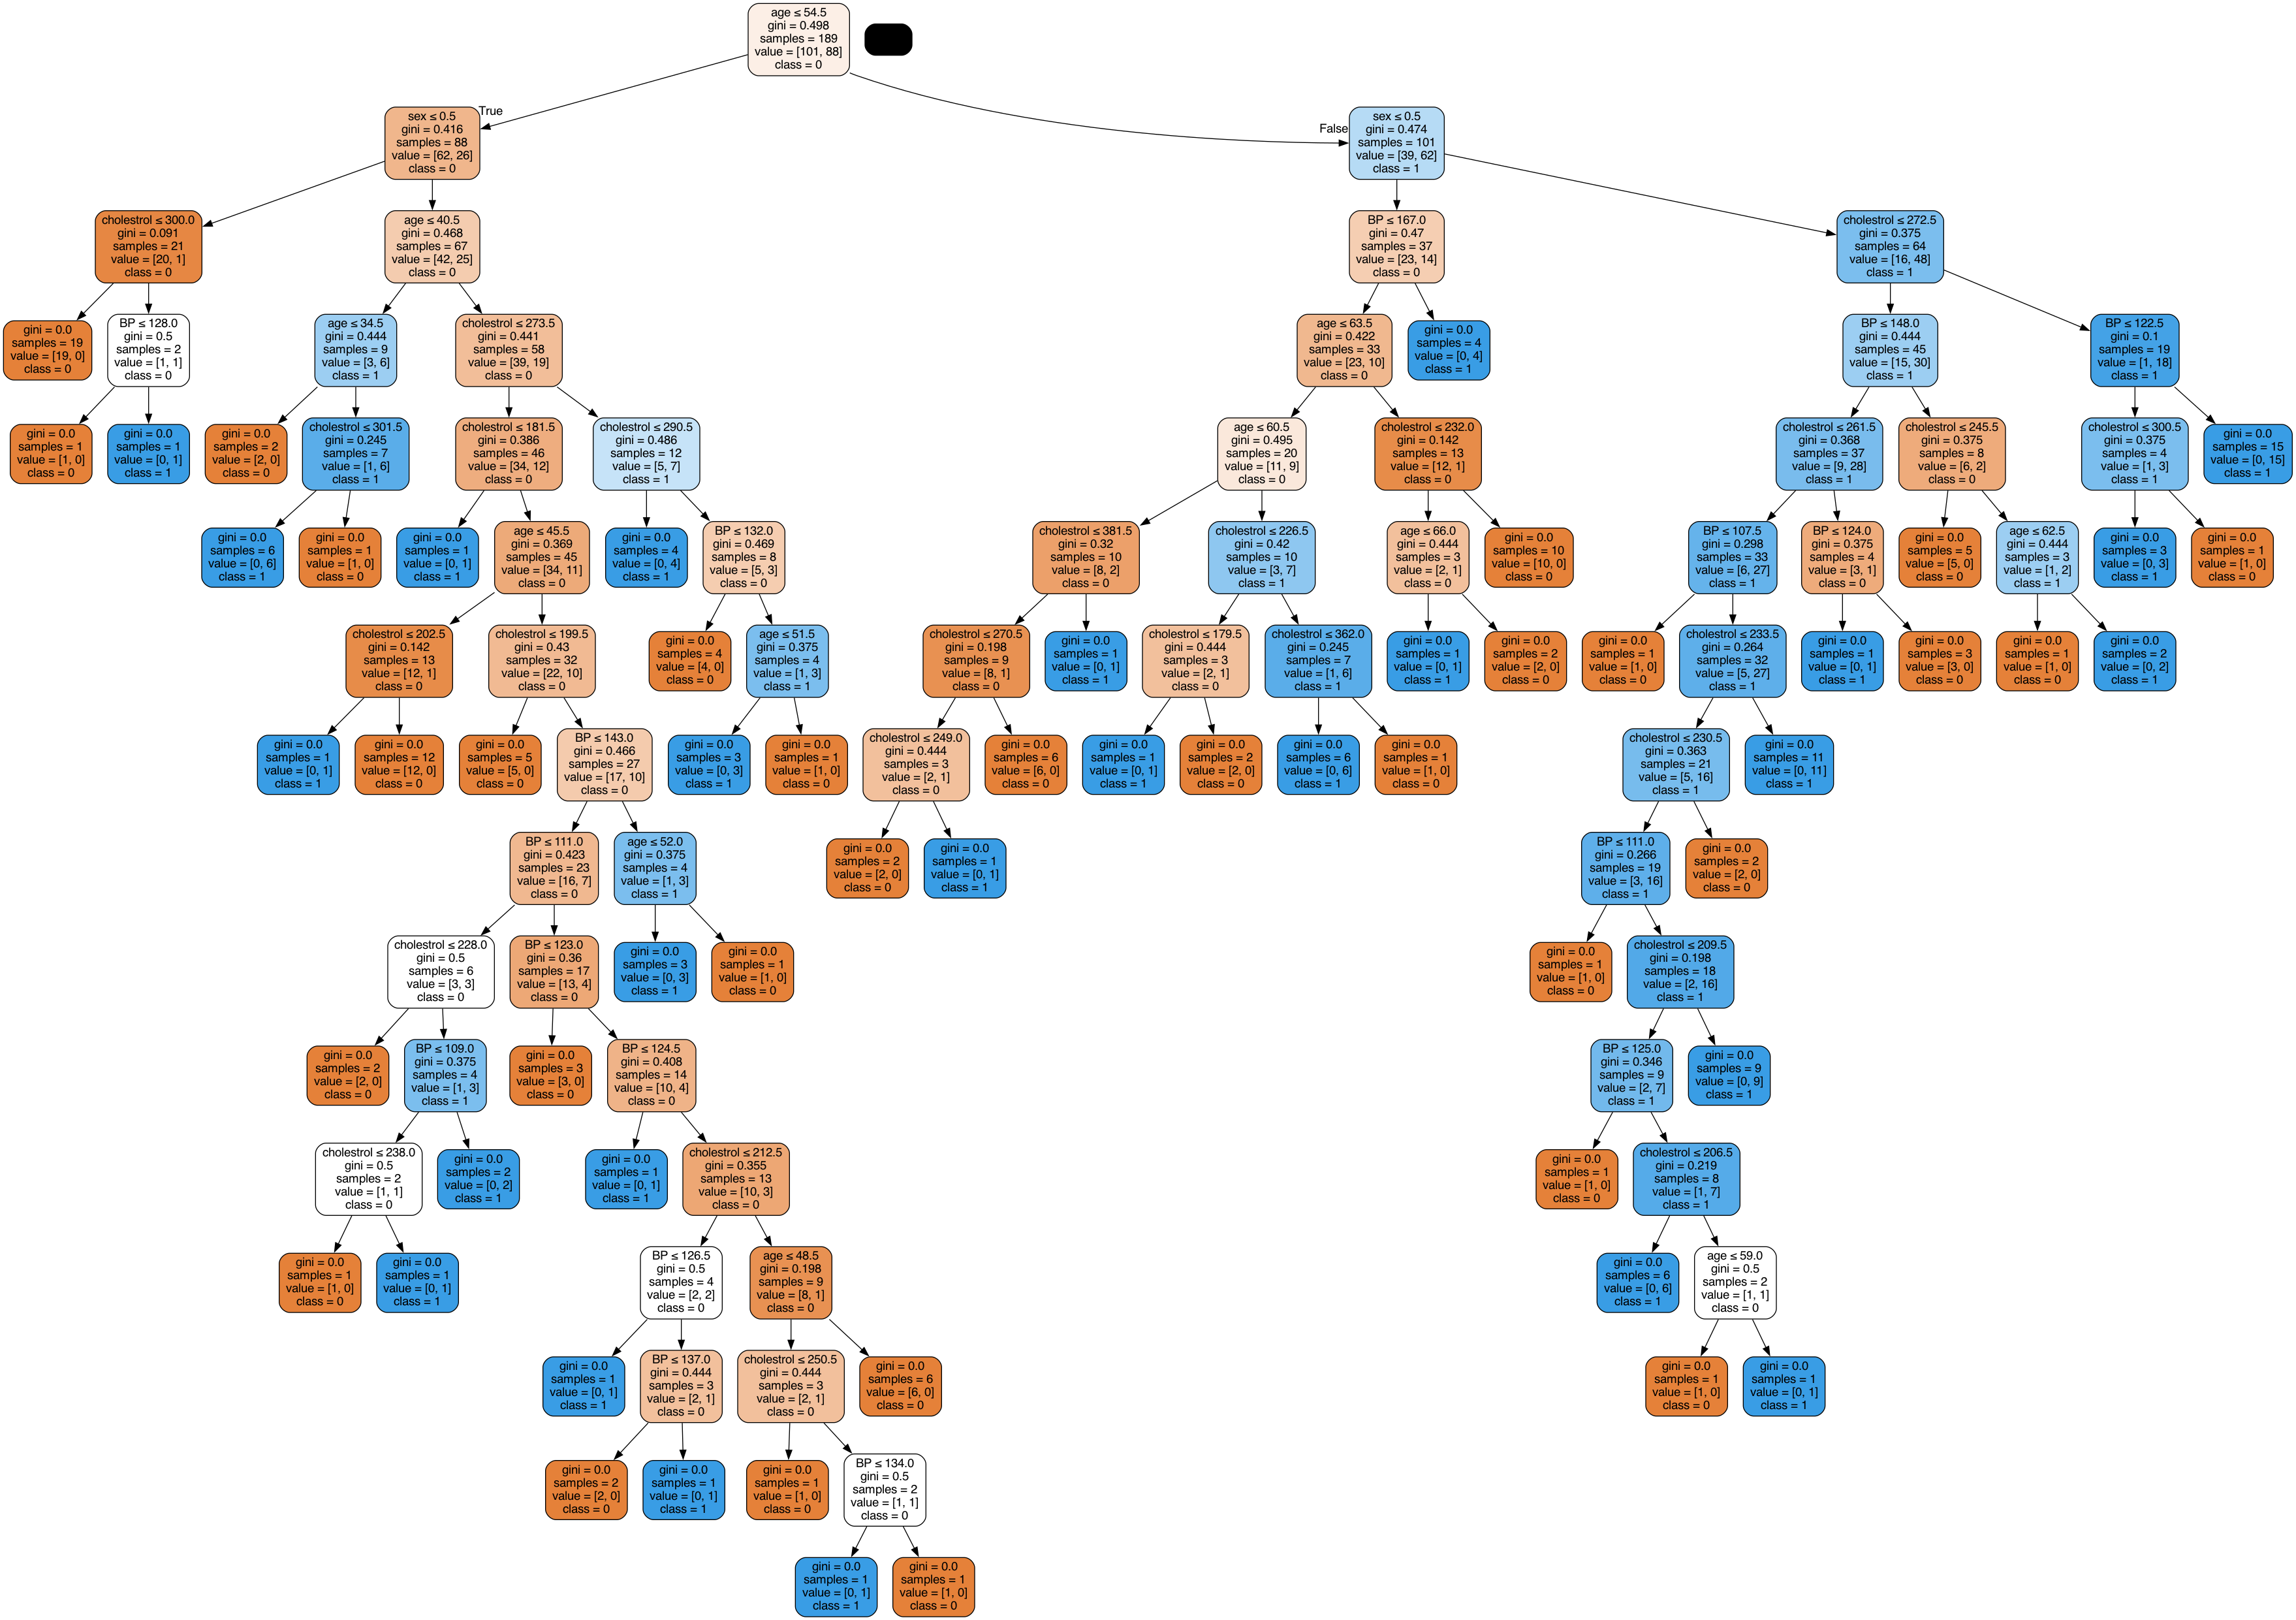

In [ ]:
visualize_tree(
    dt_default,
    feature_names=X.columns)

### Feature Importance

Identify which features the baseline tree actually used.


,Feature,Importance
0,cholestrol,0.367246
1,age,0.281151
2,BP,0.246725
3,sex,0.104878


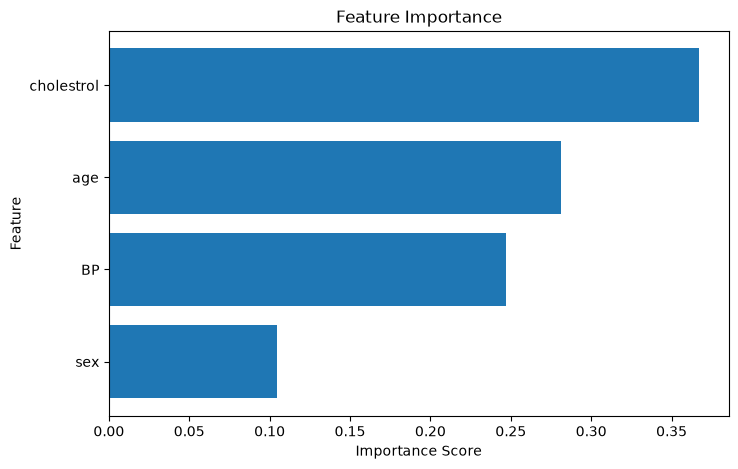

,Feature,Importance
0,cholestrol,0.367246
1,age,0.281151
2,BP,0.246725
3,sex,0.104878


In [ ]:
show_feature_importance(
    dt_default,
    feature_names=X.columns
)

# 2. Control Tree Depth Using max_depth

The default tree can continue growing until its stopping rules are reached. A deep tree may memorize training data and overfit.

Here we restrict the tree to a maximum depth of **3**.


In [ ]:
dt_max_depth = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_max_depth.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

###  Evaluate the Model

Compare the depth-controlled model with the baseline model.


In [ ]:
evaluate_model(
    dt_max_depth,
    X_train, y_train,
    X_test, y_test
)

TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 0.74

Confusion Matrix:
[[82 19]
 [30 58]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.6
Confusion Matrix:
[[35 14]
 [18 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.71      0.69        49
           1       0.50      0.44      0.47        32

    accuracy                           0.60        81
   macro avg       0.58      0.58      0.58        81
weighted avg       0.60      0.60      0.60        81



### Visualize the Decision Tree

Notice how limiting depth creates a smaller and easier-to-interpret tree.


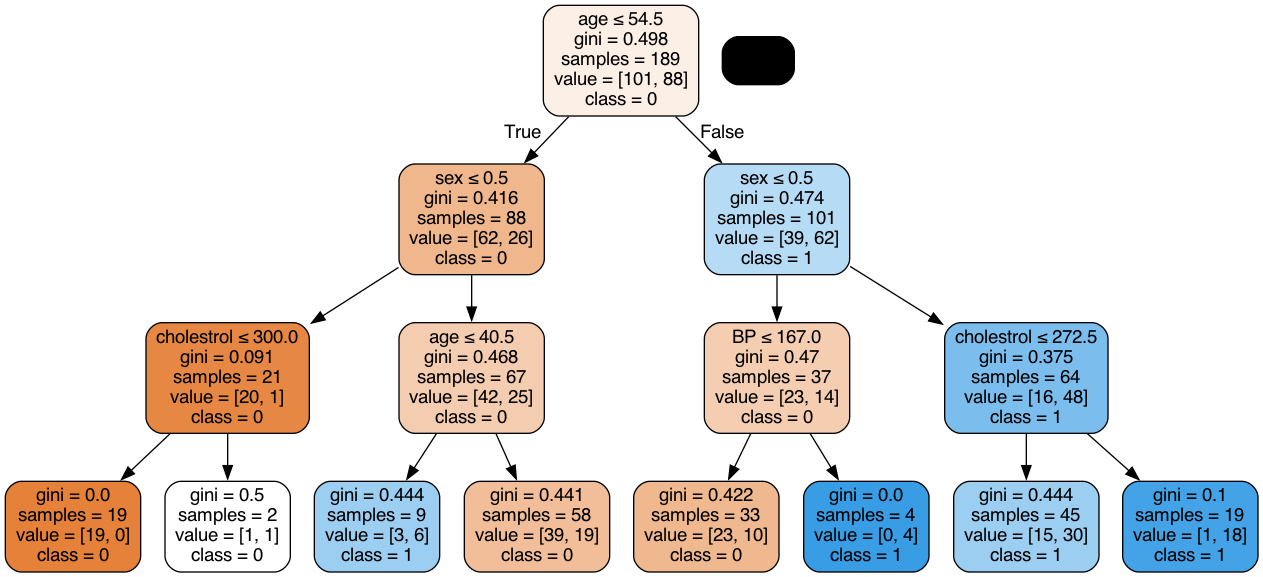

In [ ]:
visualize_tree(
    dt_max_depth,
    feature_names=X.columns
)


### Feature Importance

Check whether controlling depth changes the importance of features.


,Feature,Importance
0,age,0.409401
1,sex,0.356529
2,BP,0.125276
3,cholestrol,0.108795


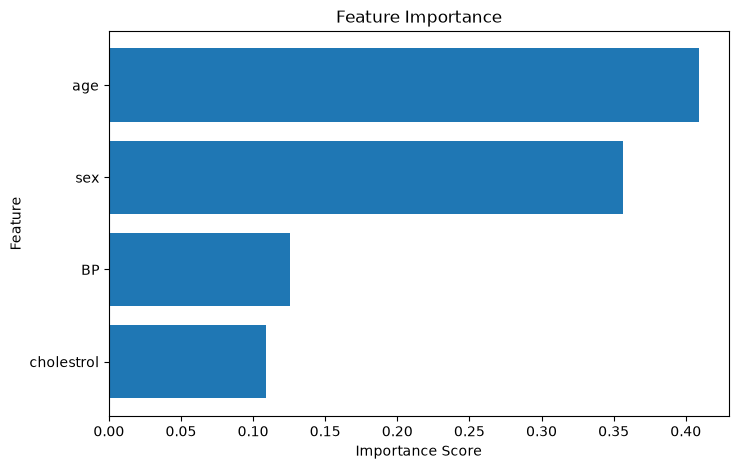

,Feature,Importance
0,age,0.409401
1,sex,0.356529
2,BP,0.125276
3,cholestrol,0.108795


In [ ]:
show_feature_importance(
    dt_max_depth,
    feature_names=X.columns
)


# 3. Control Splitting Using min_samples_split

Next, we control when a node is allowed to split.

With `min_samples_split=20`, a node must contain at least **20 samples** before the tree can split it. This prevents the model from creating many small branches.


In [ ]:
dt_min_split = DecisionTreeClassifier(
    min_samples_split=20,
    random_state=42
)

dt_min_split.fit(X_train, y_train)


,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

###  Evaluate the Model

Check whether restricting splits reduces overfitting compared with the baseline.


In [ ]:
evaluate_model(
    dt_min_split,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 0.84

Confusion Matrix:
[[85 16]
 [15 73]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.64
Confusion Matrix:
[[32 17]
 [12 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69        49
           1       0.54      0.62      0.58        32

    accuracy                           0.64        81
   macro avg       0.63      0.64      0.63        81
weighted avg       0.65      0.64      0.65        81



### Visualize the Decision Tree

Observe which branches were prevented because small nodes could not be split further.


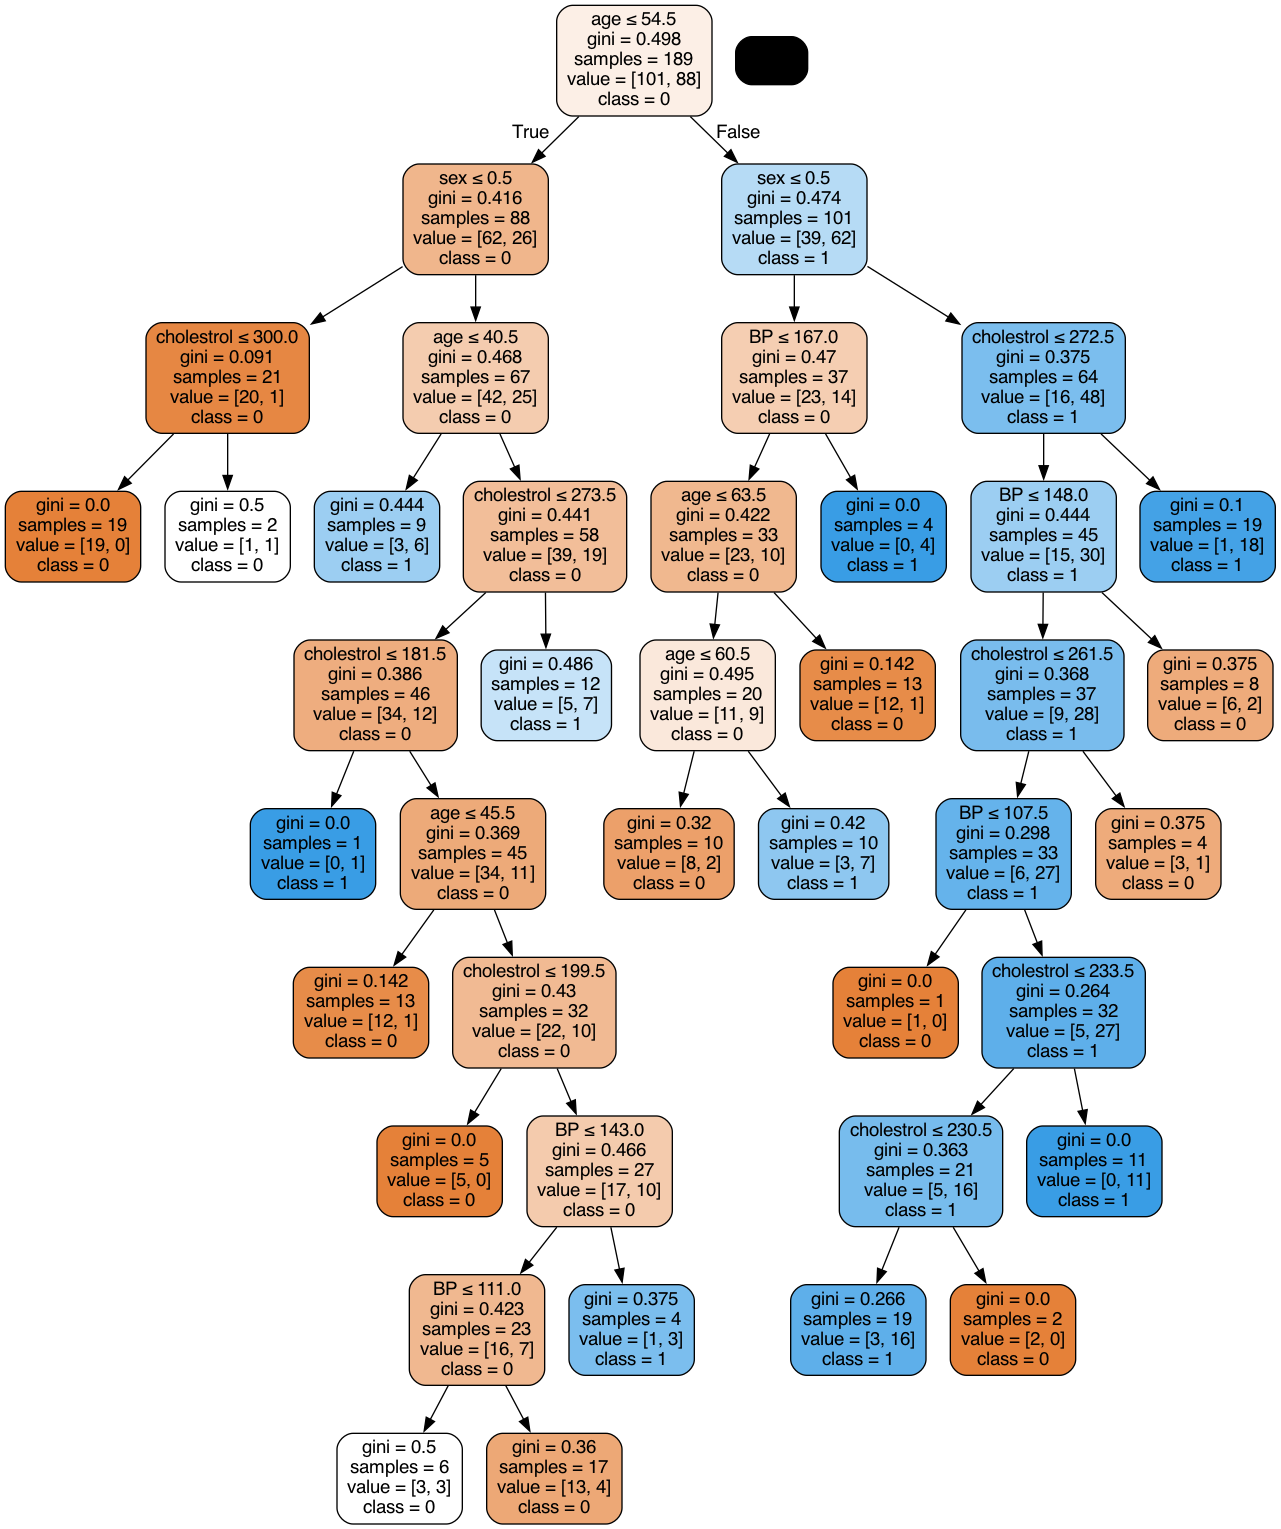

In [ ]:
visualize_tree(
    dt_min_split,
    feature_names=X.columns
)


### Feature Importance

Compare the feature importance with the earlier models.


,Feature,Importance
0,age,0.340501
1,cholestrol,0.258716
2,BP,0.203747
3,sex,0.197037


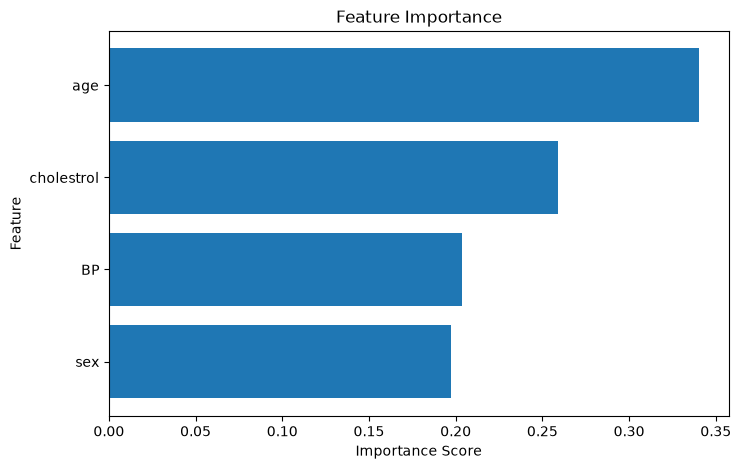

,Feature,Importance
0,age,0.340501
1,cholestrol,0.258716
2,BP,0.203747
3,sex,0.197037


In [ ]:
show_feature_importance(
    dt_min_split,
    feature_names=X.columns
)


# 4. Control Leaf Size Using min_samples_leaf

Now we control the minimum number of samples allowed in every leaf node.

With `min_samples_leaf=20`, every final leaf must contain at least **20 samples**. This strongly reduces very specific leaves based on only a few observations.


In [ ]:
dt_min_leaf = DecisionTreeClassifier(
    min_samples_leaf=20,
    random_state=42
)

dt_min_leaf.fit(X_train, y_train)


,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

###  Evaluate the Model

Compare training and testing performance after forcing larger leaf nodes.


In [ ]:
evaluate_model(
    dt_min_leaf,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 0.7

Confusion Matrix:
[[85 16]
 [40 48]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.64
Confusion Matrix:
[[38 11]
 [18 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.72        49
           1       0.56      0.44      0.49        32

    accuracy                           0.64        81
   macro avg       0.62      0.61      0.61        81
weighted avg       0.63      0.64      0.63        81



### Visualize the Decision Tree

Observe how requiring larger leaves simplifies the tree.


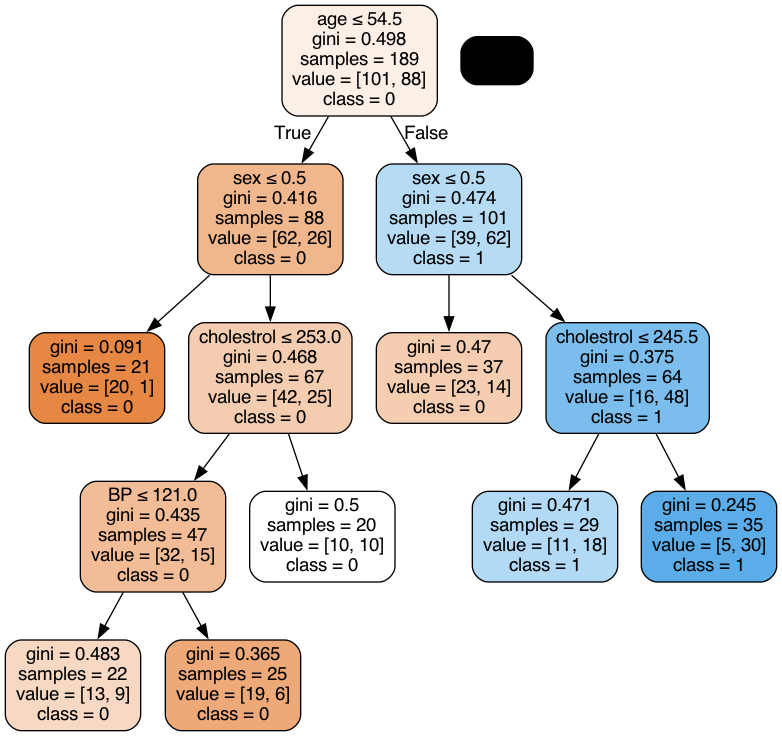

In [ ]:
visualize_tree(
    dt_min_leaf,
    feature_names=X.columns
)


### Feature Importance

Check how feature importance changes when small, specific splits are not allowed.


,Feature,Importance
0,sex,0.433401
1,age,0.418957
2,cholestrol,0.118242
3,BP,0.029401


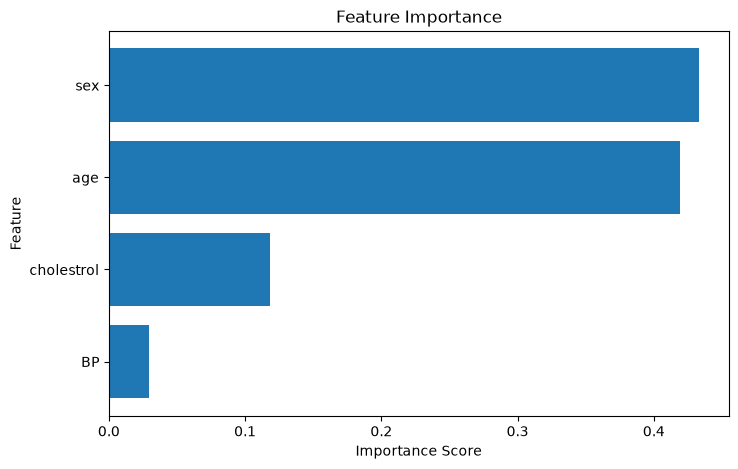

,Feature,Importance
0,sex,0.433401
1,age,0.418957
2,cholestrol,0.118242
3,BP,0.029401


In [ ]:
show_feature_importance(
    dt_min_leaf,
    feature_names=X.columns
)


# 5. Change the Split Criterion to Entropy

So far, the models use the default **Gini impurity** criterion.

Now we keep `min_samples_leaf=20` and change the split criterion to **Entropy**. The tree now selects splits based on the reduction in uncertainty, commonly described through Information Gain.


In [ ]:
dt_entropy = DecisionTreeClassifier(
    min_samples_leaf=20,
    random_state=42,
    criterion="entropy"
)

dt_entropy.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamp

###  Evaluate the Model

Compare the Entropy-based model with the previous Gini-based model.


In [ ]:
evaluate_model(
    dt_entropy,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 0.7

Confusion Matrix:
[[85 16]
 [40 48]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.64
Confusion Matrix:
[[38 11]
 [18 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.72        49
           1       0.56      0.44      0.49        32

    accuracy                           0.64        81
   macro avg       0.62      0.61      0.61        81
weighted avg       0.63      0.64      0.63        81



### Visualize the Decision Tree

Observe whether changing the impurity measure produces different split conditions.


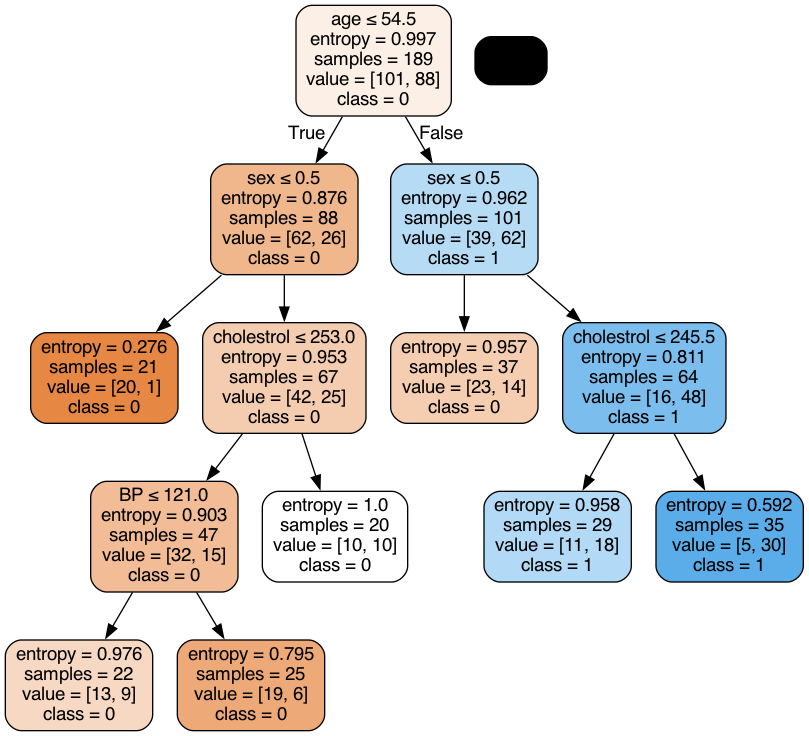

In [ ]:
visualize_tree(
    dt_entropy,
    feature_names=X.columns
)


### Feature Importance

Compare which features become important under the Entropy criterion.


,Feature,Importance
0,sex,0.462601
1,age,0.377982
2,cholestrol,0.129573
3,BP,0.029843


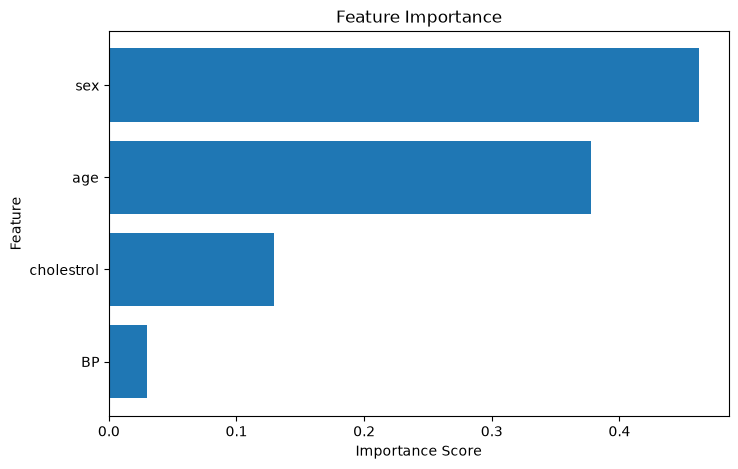

,Feature,Importance
0,sex,0.462601
1,age,0.377982
2,cholestrol,0.129573
3,BP,0.029843


In [ ]:
show_feature_importance(
    dt_entropy,
    feature_names=X.columns
)


# 6. Handle Class Imbalance Using Balanced Class Weights

If the classes are imbalanced, the majority class can dominate the training process.

`class_weight='balanced'` automatically gives greater importance to classes with fewer samples.


In [ ]:
dt_balanced = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt_balanced.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

###  Evaluate the Model

Compare the balanced model with the baseline, especially using the classification report and confusion matrix.


In [ ]:
evaluate_model(
    dt_balanced,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 1.0

Confusion Matrix:
[[101   0]
 [  0  88]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.64
Confusion Matrix:
[[32 17]
 [12 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69        49
           1       0.54      0.62      0.58        32

    accuracy                           0.64        81
   macro avg       0.63      0.64      0.63        81
weighted avg       0.65      0.64      0.65        81



### Visualize the Decision Tree

Observe whether class weights change the selected splits and the structure of the tree.


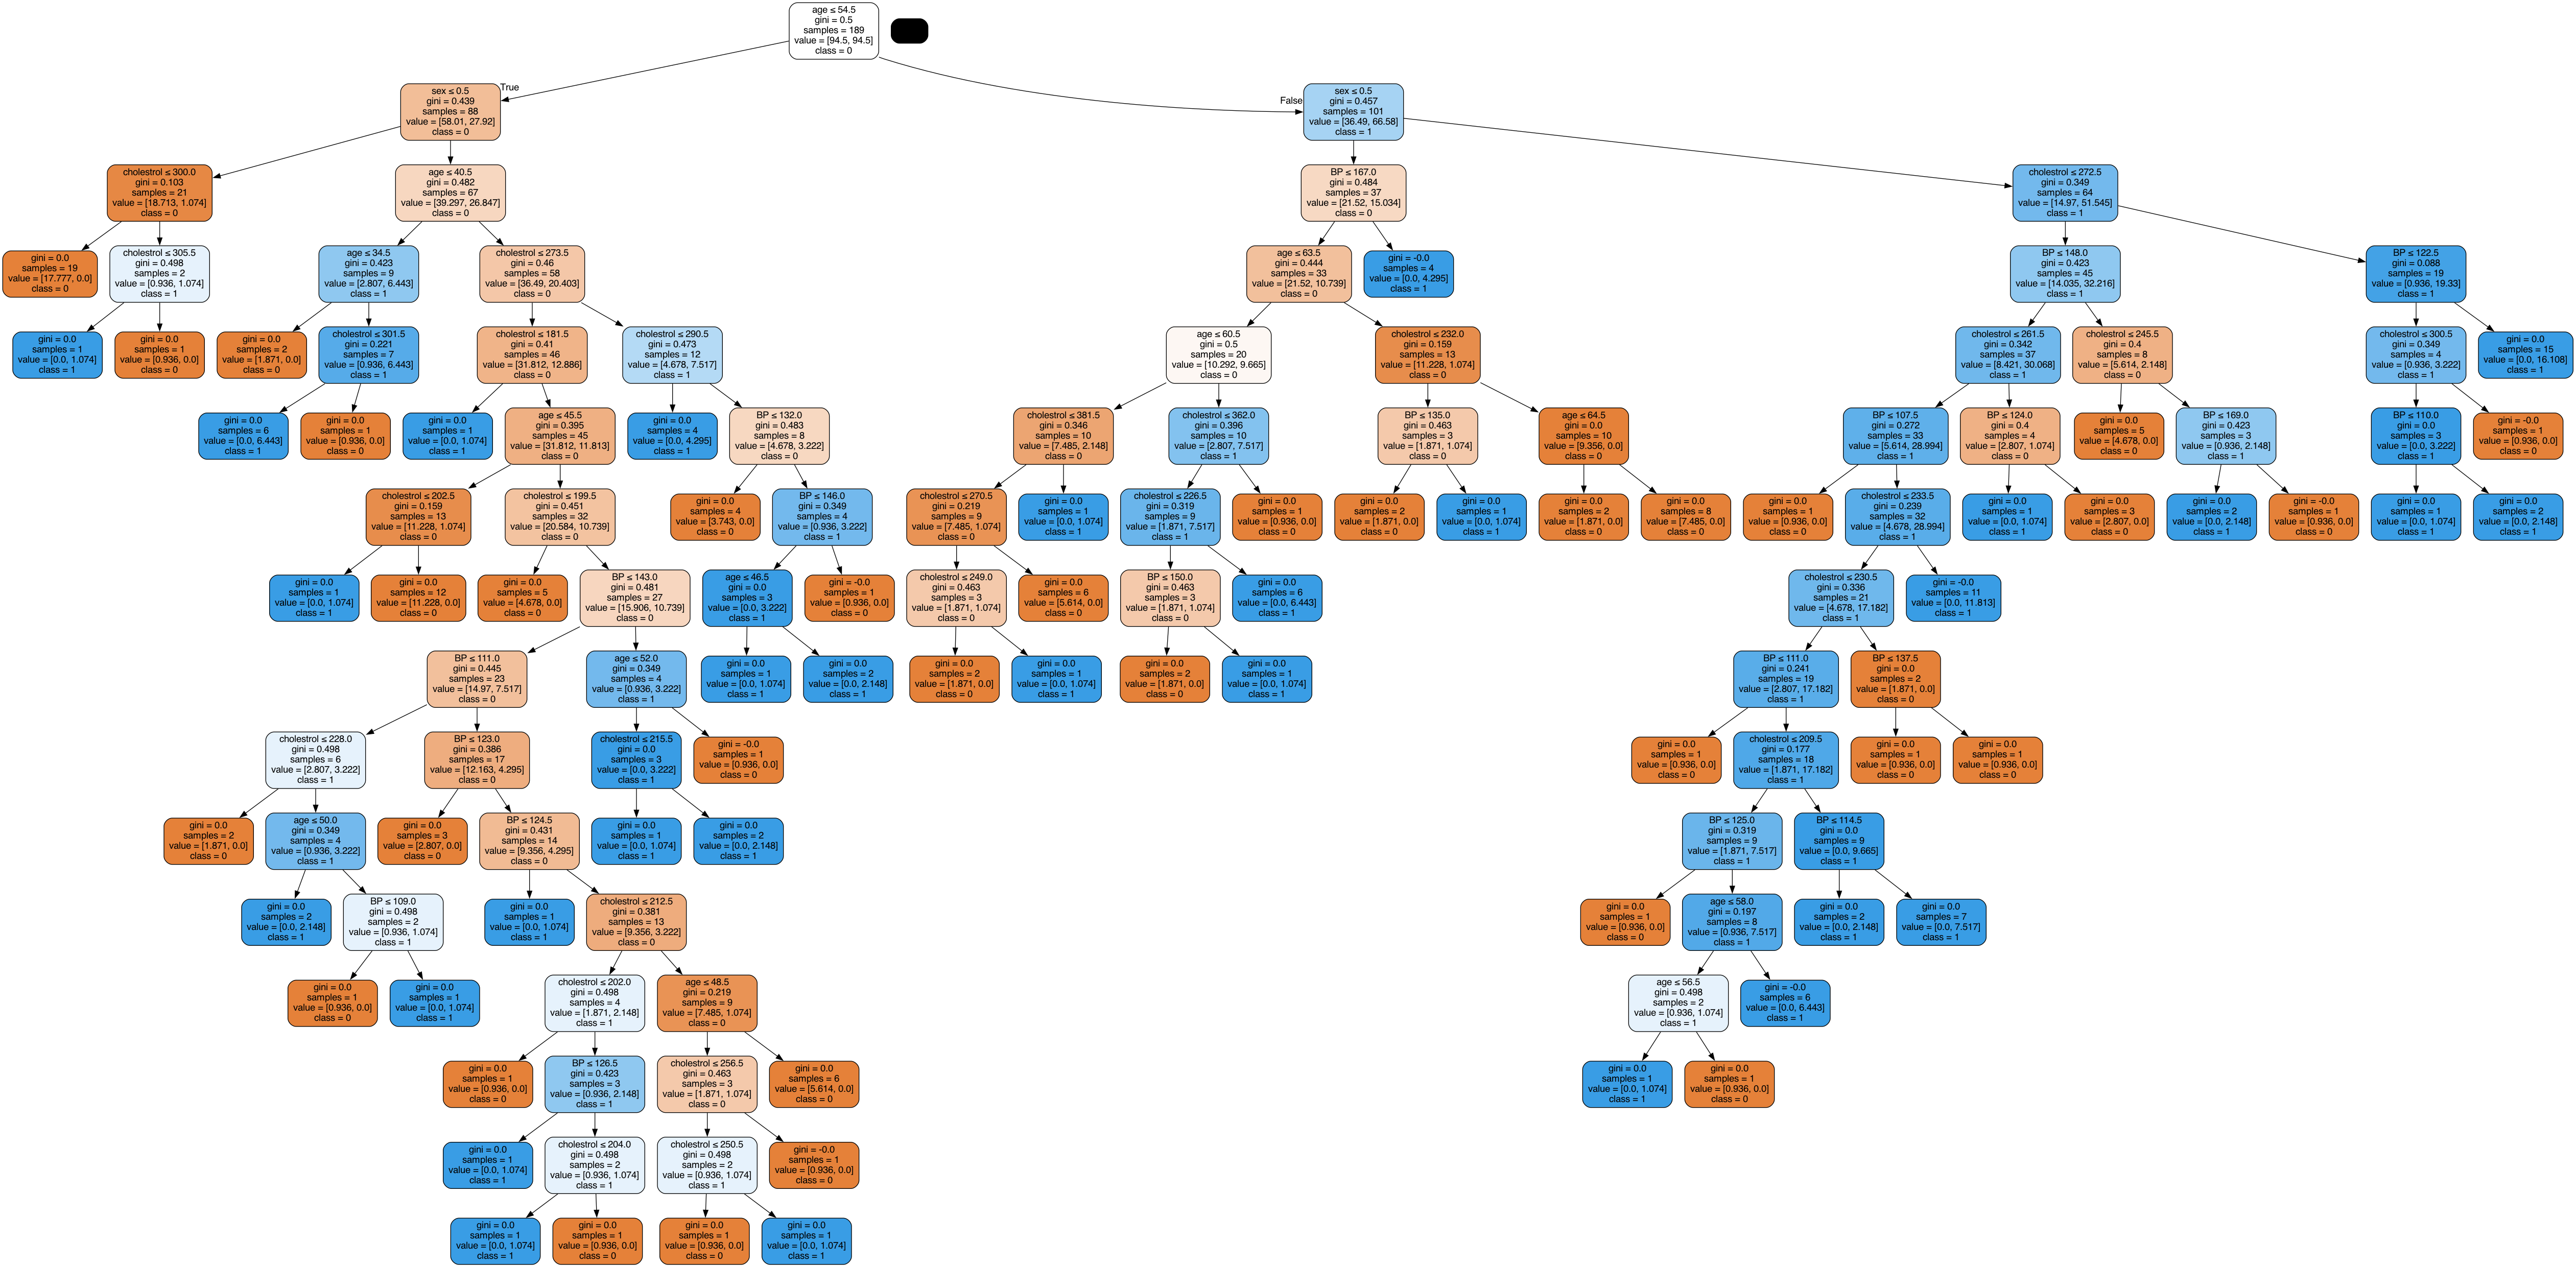

In [ ]:
visualize_tree(
    dt_balanced,
    feature_names=X.columns
)


### Feature Importance

Check whether the importance of features changes when minority-class errors receive more importance.


,Feature,Importance
0,cholestrol,0.372006
1,BP,0.268920
2,age,0.253200
3,sex,0.105874


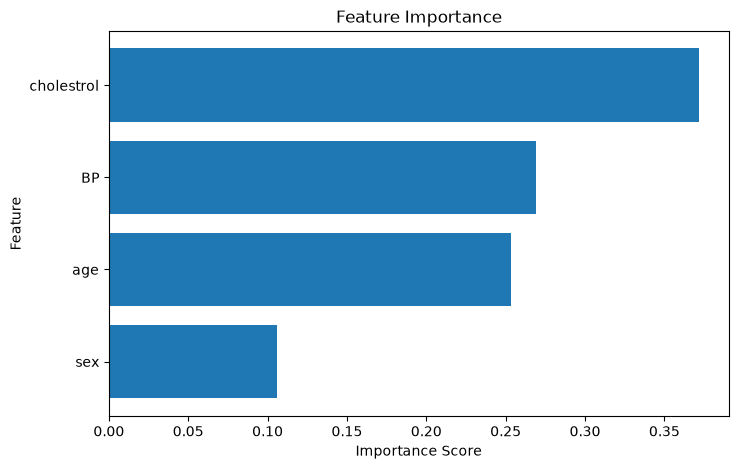

,Feature,Importance
0,cholestrol,0.372006
1,BP,0.268920
2,age,0.253200
3,sex,0.105874


In [ ]:
show_feature_importance(
    dt_balanced,
    feature_names=X.columns
)


# 7. Handle Class Imbalance Using Custom Class Weights

Custom class weights allow us to manually control how important each class is.

In this example, Class `1` is given twice the weight of Class `0`.


In [ ]:
custom_weights = {
    0: 1,
    1: 2
}

dt_custom_weight = DecisionTreeClassifier(
    class_weight=custom_weights,
    random_state=42
)

dt_custom_weight.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 1, 1: 2}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features 

###  Evaluate the Model

Compare the custom-weight model with both the baseline and automatically balanced model.


In [ ]:
evaluate_model(
    dt_custom_weight,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 1.0

Confusion Matrix:
[[101   0]
 [  0  88]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.62
Confusion Matrix:
[[31 18]
 [13 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.63      0.67        49
           1       0.51      0.59      0.55        32

    accuracy                           0.62        81
   macro avg       0.61      0.61      0.61        81
weighted avg       0.63      0.62      0.62        81



### Visualize the Decision Tree

Observe how manually increasing the importance of Class 1 can change the tree.


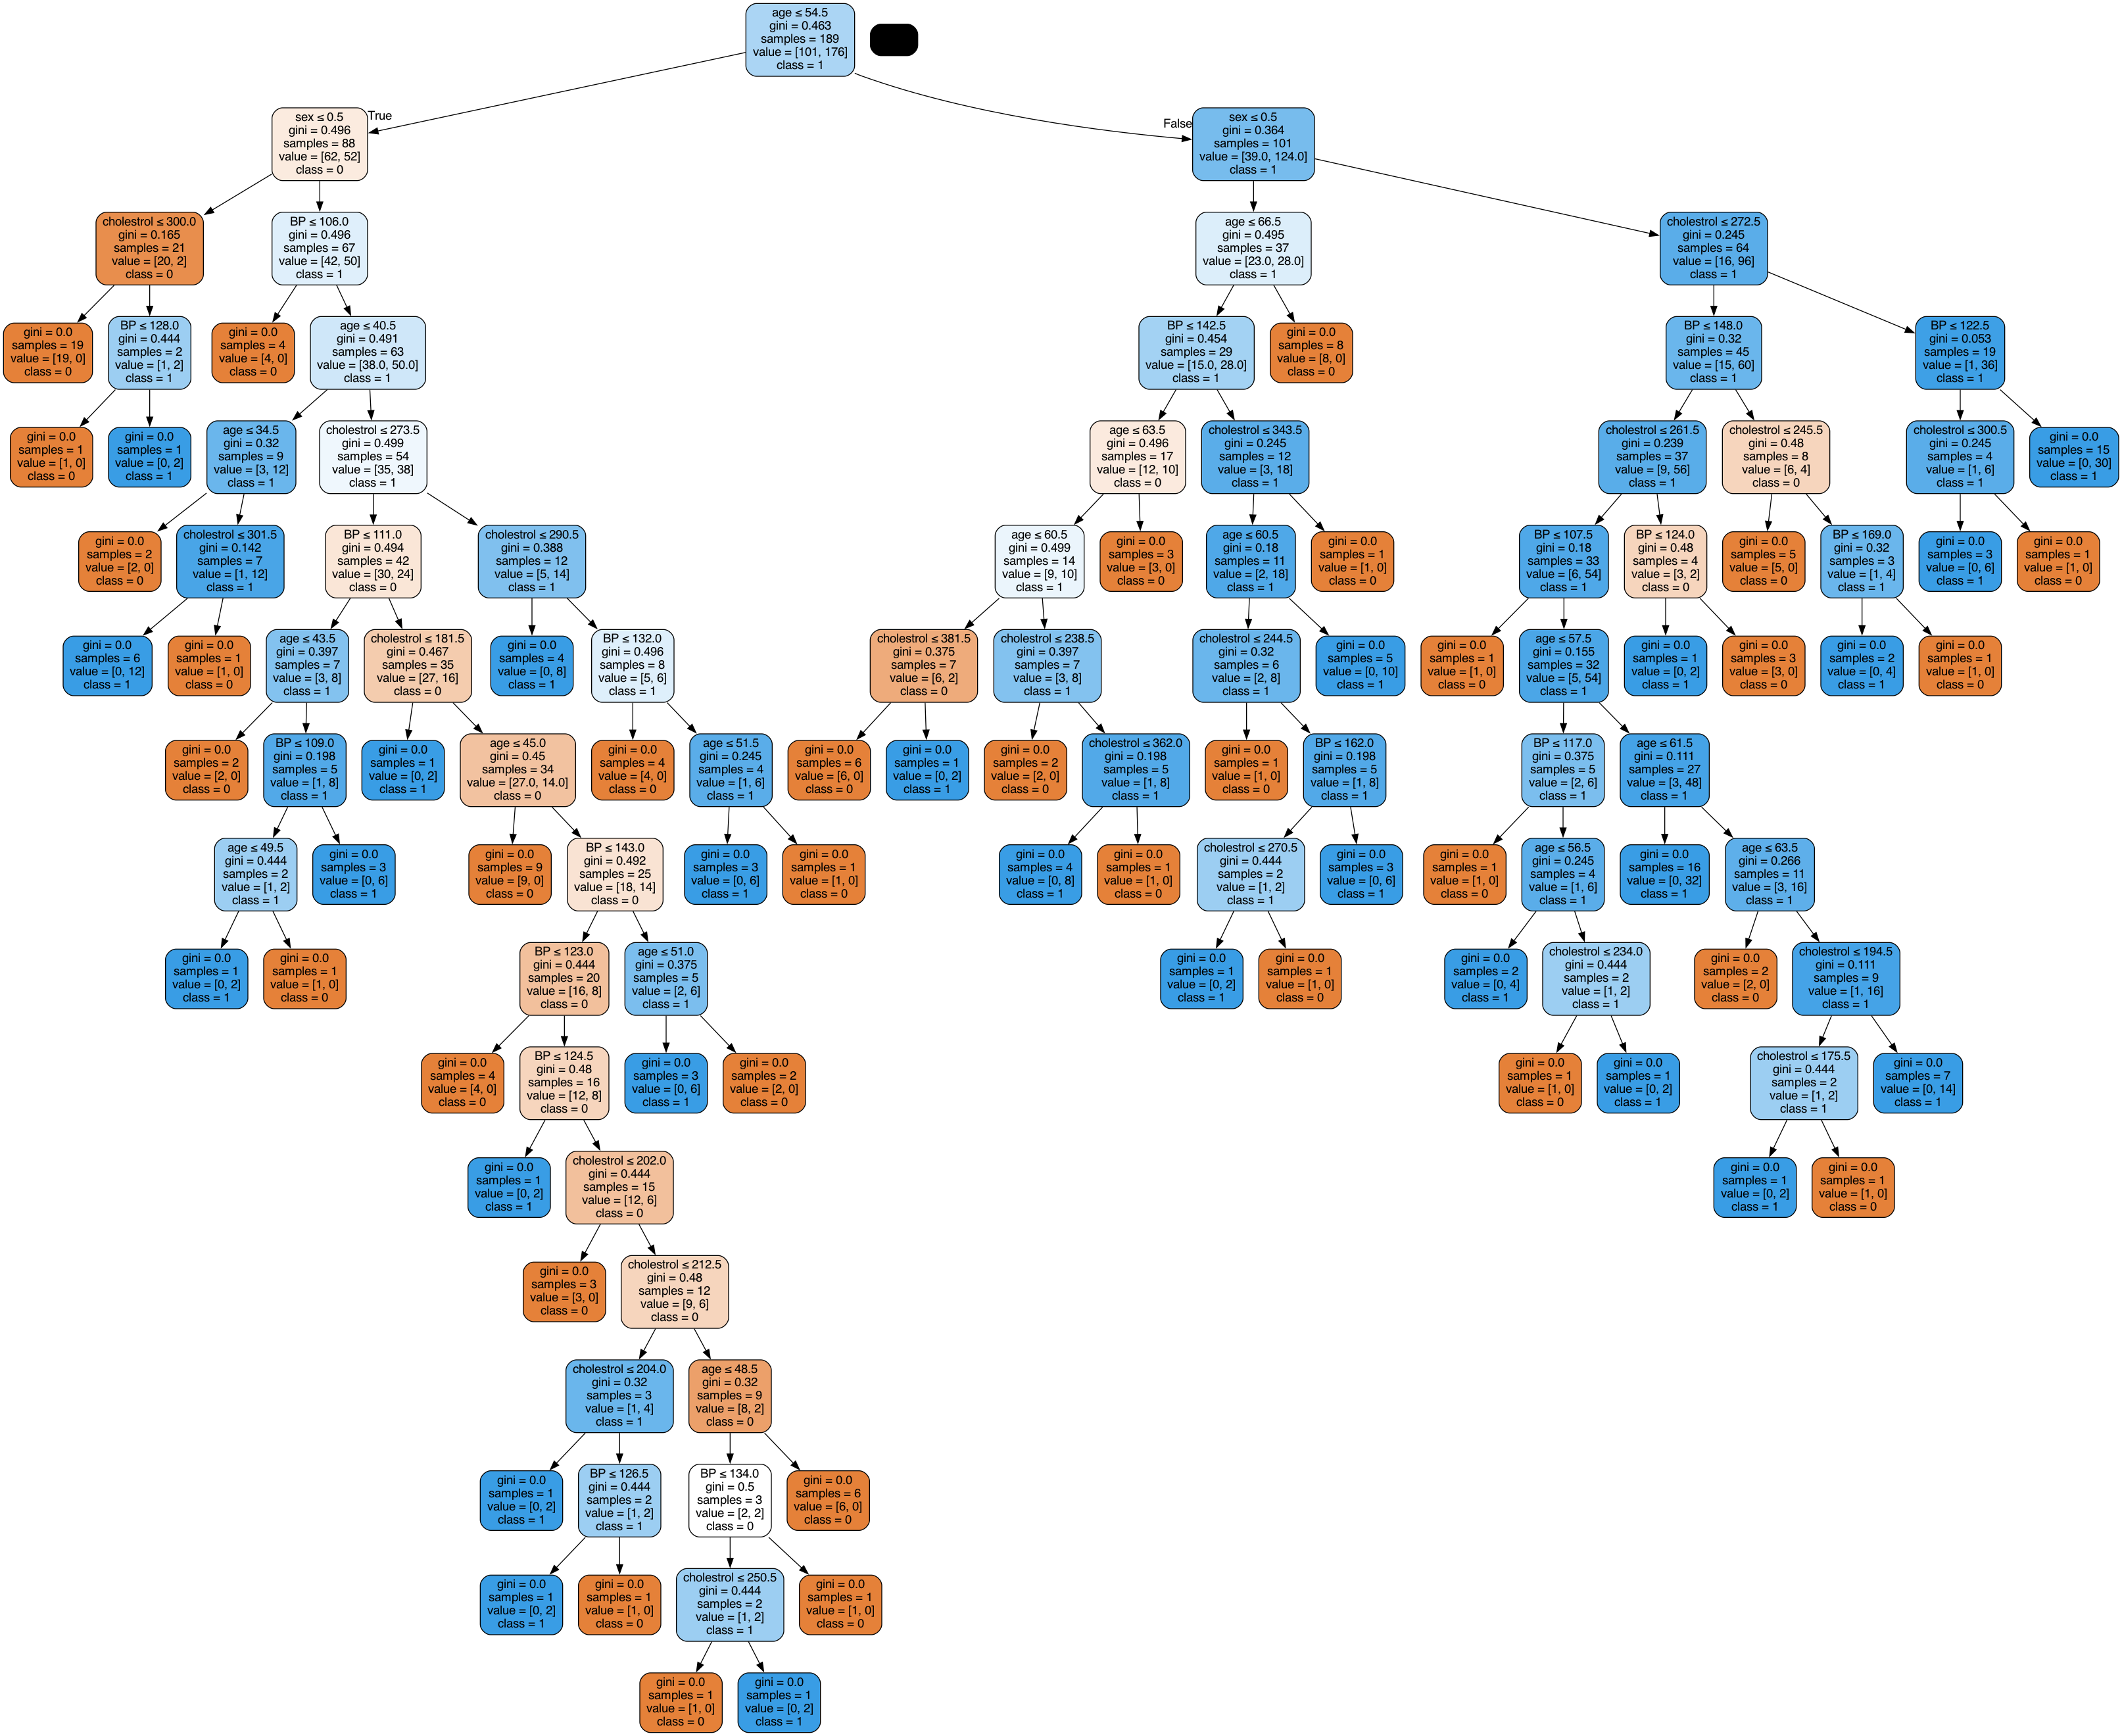

In [ ]:
visualize_tree(
    dt_custom_weight,
    feature_names=X.columns
)


### Feature Importance

Check which features the custom-weight model considers most important.


,Feature,Importance
0,age,0.344257
1,cholestrol,0.299990
2,BP,0.247244
3,sex,0.108509


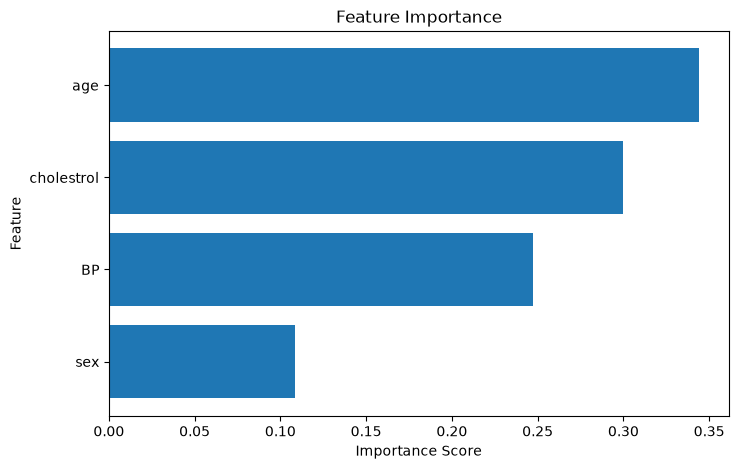

,Feature,Importance
0,age,0.344257
1,cholestrol,0.299990
2,BP,0.247244
3,sex,0.108509


In [ ]:
show_feature_importance(
    dt_custom_weight,
    feature_names=X.columns
)


# 8. Final Hyperparameter Tuning Using GridSearchCV

After manually experimenting with individual hyperparameters, we now tune multiple parameters together.

This is the natural progression:

```text
Default Model
      ↓
Control One Parameter at a Time
      ↓
Understand Its Effect
      ↓
Test Multiple Parameters Together
      ↓
GridSearchCV Selects the Best Combination
```

The following grid tests all combinations provided below using cross-validation.


In [ ]:
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Create the base Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Define cross-validation folds
cv_ = 2

# Define the hyperparameter grid
param_grid = {
    'criterion': [
        'gini',
        'entropy',
        'log_loss'
    ],
    'max_depth': [
        None,
        2,
        3
    ],
    'min_samples_split': [
        2,
        3
    ],
    'min_samples_leaf': [
        1,
        2
    ],
    'min_weight_fraction_leaf': [
        0.0
    ],
    'max_features': [
        None,
        'sqrt',
        'log2'
    ],
    'max_leaf_nodes': [
        None,
        5,
        4
    ],
    'min_impurity_decrease': [
        0.0
    ],
    'class_weight': [
        None,
        'balanced',
        {0: 1, 1: 2}
    ],
    'splitter': [
        'best',
        'random'
    ]
}

# Calculate the total number of hyperparameter combinations
total_combinations = len(list(ParameterGrid(param_grid)))

# Calculate the total number of model fits
total_fits = total_combinations * cv_

print("Total hyperparameter combinations:", total_combinations)
print("Total model fits:", total_fits)


Total hyperparameter combinations: 1944
Total model fits: 3888


## 8.1 Train GridSearchCV


In [ ]:
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv_,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

best_dt = grid_search.best_estimator_


Fitting 2 folds for each of 1944 candidates, totalling 3888 fits

Best Parameters:
{'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 5, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'splitter': 'random'}

Best Cross-Validation Accuracy:
0.7248040313549832


## 8.2 Evaluate the Best GridSearchCV Model


In [ ]:
evaluate_model(
    best_dt,
    X_train, y_train,
    X_test, y_test
)


TRAINING PERFORMANCE
--------------------------------------------------
Accuracy: 0.74

Confusion Matrix:
[[85 16]
 [34 54]]

TESTING PERFORMANCE
--------------------------------------------------
Accuracy: 0.63
Confusion Matrix:
[[35 14]
 [16 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        49
           1       0.53      0.50      0.52        32

    accuracy                           0.63        81
   macro avg       0.61      0.61      0.61        81
weighted avg       0.63      0.63      0.63        81



## 8.3 Visualize the Best Decision Tree


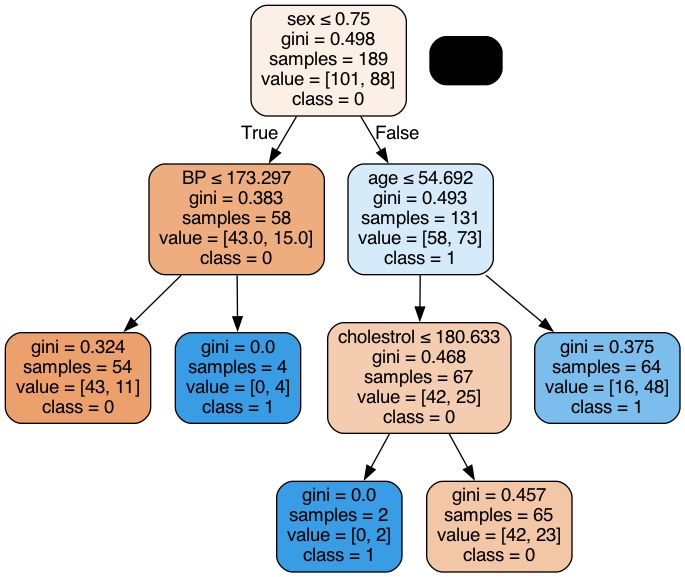

In [ ]:
visualize_tree(
    best_dt,
    feature_names=X.columns
)


## 8.4 Feature Importance


,Feature,Importance
0,age,0.407602
1,sex,0.314331
2,BP,0.207040
3,cholestrol,0.071026


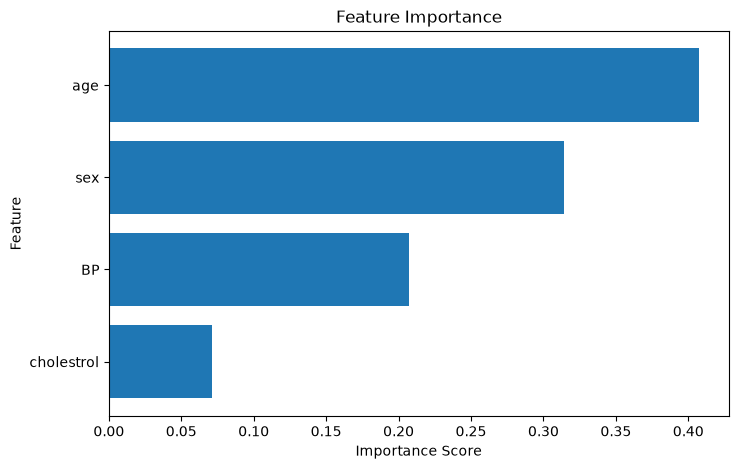

,Feature,Importance
0,age,0.407602
1,sex,0.314331
2,BP,0.207040
3,cholestrol,0.071026


In [ ]:
show_feature_importance(
    best_dt,
    feature_names=X.columns
)


# 9. Final Model Comparison

Finally, compare all models side by side using test accuracy.

For an imbalanced classification problem, also use the classification reports and confusion matrices from the previous sections to compare precision, recall, and F1-score.


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Default Decision Tree",
        "max_depth=3",
        "min_samples_split=20",
        "min_samples_leaf=20",
        "min_samples_leaf=20 + Entropy",
        "class_weight='balanced'",
        "Custom Class Weight {0:1, 1:2}",
        "Best GridSearchCV Model"
    ],

        "Train Accuracy": [
        accuracy_score(y_train, dt_default.predict(X_train)),
        accuracy_score(y_train, dt_max_depth.predict(X_train)),
        accuracy_score(y_train, dt_min_split.predict(X_train)),
        accuracy_score(y_train, dt_min_leaf.predict(X_train)),
        accuracy_score(y_train, dt_entropy.predict(X_train)),
        accuracy_score(y_train, dt_balanced.predict(X_train)),
        accuracy_score(y_train, dt_custom_weight.predict(X_train)),
        accuracy_score(y_train, best_dt.predict(X_train))
    ],

    "Test Accuracy": [
        accuracy_score(y_test, dt_default.predict(X_test)),
        accuracy_score(y_test, dt_max_depth.predict(X_test)),
        accuracy_score(y_test, dt_min_split.predict(X_test)),
        accuracy_score(y_test, dt_min_leaf.predict(X_test)),
        accuracy_score(y_test, dt_entropy.predict(X_test)),
        accuracy_score(y_test, dt_balanced.predict(X_test)),
        accuracy_score(y_test, dt_custom_weight.predict(X_test)),
        accuracy_score(y_test, best_dt.predict(X_test))
    ]
})

display(
    model_comparison
    .sort_values(by="Test Accuracy", ascending=False)
    .reset_index(drop=True)
)


,Model,Train Accuracy,Test Accuracy
0,min_samples_split=20,0.835979,0.641975
1,min_samples_leaf=20,0.703704,0.641975
2,min_samples_leaf=20 + Entropy,0.703704,0.641975
3,class_weight='balanced',1.000000,0.641975
4,Default Decision Tree,1.000000,0.629630
5,Best GridSearchCV Model,0.735450,0.629630
6,"Custom Class Weight {0:1, 1:2}",1.000000,0.617284
7,max_depth=3,0.740741,0.604938
